# 📧 Email Spam Detection using Machine Learning

## Project Overview

This project aims to build a Machine Learning model that can automatically classify emails as **Spam** or **Ham (Not Spam)** based on their message content.

Email spam detection is one of the most common applications of Machine Learning and Natural Language Processing (NLP). The model is trained on labeled email messages and learns patterns that help distinguish spam emails from legitimate emails.

This project follows a complete machine learning workflow including data loading, data cleaning, exploratory data analysis, text preprocessing, feature extraction, model training, model evaluation, and prediction.

## Step 1: Import Required Libraries

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Step 2: Load the Dataset

In [2]:
# Load the dataset
df = pd.read_csv("spam.csv", encoding="latin-1")

# Display the first 5 rows
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## Step 3: Understand the Dataset

In [4]:
# Display the shape of the dataset
print("Dataset Shape:", df.shape)

print("\n" + "="*50)

# Display column names
print("Column Names:")
print(df.columns)

print("\n" + "="*50)

# Display dataset information
print("Dataset Information:")
df.info()

print("\n" + "="*50)

# Check missing values
print("Missing Values:")
print(df.isnull().sum())

Dataset Shape: (5572, 5)

Column Names:
Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB

Missing Values:
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


## Step 4: Data Cleaning

In [5]:
# Remove unnecessary columns
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])

# Rename columns for better readability
df = df.rename(columns={
    "v1": "Category",
    "v2": "Message"
})

# Display the first five rows after cleaning
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Insight

The dataset was cleaned by removing three unnecessary columns that contained only missing values. The remaining columns were renamed to "Category" and "Message" to improve readability and make the dataset easier to understand.

## Step 5: Check for Duplicate Values

In [6]:
# Check the number of duplicate records
print("Number of Duplicate Records:", df.duplicated().sum())

Number of Duplicate Records: 403


In [7]:
# Remove duplicate records
df = df.drop_duplicates()

# Display the new shape of the dataset
print("Dataset Shape after removing duplicates:", df.shape)

Dataset Shape after removing duplicates: (5169, 2)


### Insight

Duplicate email records were identified and removed from the dataset. Removing duplicate entries helps improve data quality and ensures that the Machine Learning model is trained on unique email messages.

## Step 6: Exploratory Data Analysis (EDA)

In [8]:
# Count the number of Spam and Ham messages
df["Category"].value_counts()

Category
ham     4516
spam     653
Name: count, dtype: int64

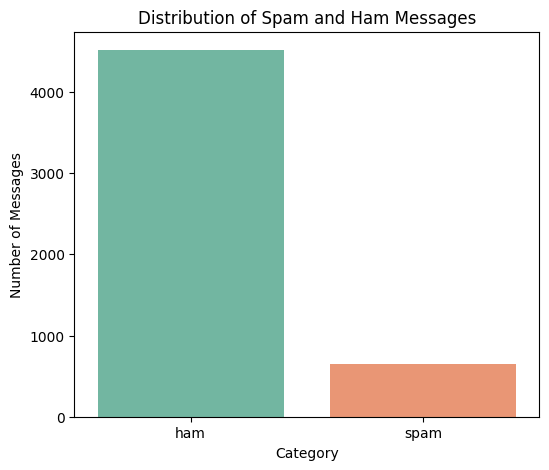

In [9]:
# Visualize the distribution of Spam and Ham messages

plt.figure(figsize=(6,5))

sns.countplot(
    x="Category",
    data=df,
    palette="Set2"
)

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Category")
plt.ylabel("Number of Messages")

plt.show()

In [10]:
# Display percentage distribution

df["Category"].value_counts(normalize=True) * 100

Category
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64

### Insight

The dataset contains two categories of messages: "Ham" (legitimate messages) and "Spam" (unwanted messages).

From the visualization, it is evident that the dataset contains significantly more "Ham" messages than "Spam" messages. This indicates that the dataset is imbalanced, which is a common characteristic of real-world spam detection datasets.

## Step 7: Feature Engineering

In [11]:
# Create a new feature called Message_Length

df["Message_Length"] = df["Message"].apply(len)

# Display the first five rows
df.head()

,Category,Message,Message_Length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


### Insight

A new feature called **Message_Length** was created by calculating the number of characters in each email message.

This feature may help the Machine Learning model distinguish between spam and ham messages, as spam messages are often longer and contain promotional content.

## Step 8: Analyze Message Length

In [12]:
# Display statistical summary of message length

df["Message_Length"].describe()

count    5169.000000
mean       78.977945
std        58.236293
min         2.000000
25%        36.000000
50%        60.000000
75%       117.000000
max       910.000000
Name: Message_Length, dtype: float64

In [13]:
# Compare message length for Spam and Ham

df.groupby("Category")["Message_Length"].describe()

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
ham,4516.0,70.459256,56.358207,2.0,34.0,52.0,90.0,910.0
spam,653.0,137.891271,30.137753,13.0,132.0,149.0,157.0,224.0


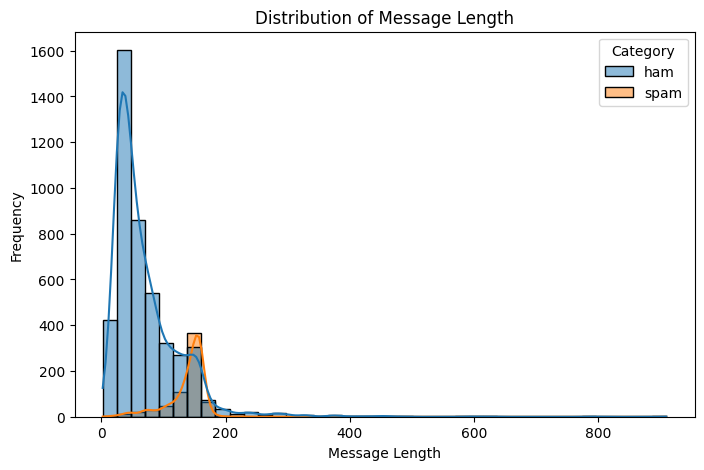

In [15]:
# Distribution of Message Length

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Message_Length",
    hue="Category",
    bins=40,
    kde=True
)

plt.title("Distribution of Message Length")
plt.xlabel("Message Length")
plt.ylabel("Frequency")

plt.show()

### Insight

The distribution plot shows that spam messages generally tend to be longer than ham messages.

This indicates that **Message_Length** is a useful feature for distinguishing between spam and legitimate messages.

## Step 9: Text Preprocessing and Feature Extraction

In [16]:
# Separate Features and Target Variable

X = df["Message"]
y = df["Category"]

### Why are we separating X and y?

- **X (Features):** Contains the email messages that will be used for prediction.
- **y (Target):** Contains the labels (**Spam** or **Ham**) that the model needs to learn.

The model will learn the relationship between the message content and its corresponding category.

In [17]:
# Convert text data into numerical features

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(X)

### Insight

Machine Learning algorithms cannot understand text directly.

The "CountVectorizer" converts each email into a numerical feature vector by counting the occurrence of each word.

This transformation enables the Machine Learning model to learn patterns from textual data.

## Step 10: Split the Dataset into Training and Testing Sets

In [18]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
# Display the shape of training and testing datasets

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

Training Data Shape : (4135, 8672)
Testing Data Shape  : (1034, 8672)


### Insight

The dataset was divided into "80% training data" and "20% testing data".

The training data is used to train the Machine Learning model, while the testing data is used to evaluate its performance on unseen email messages.

## Step 11: Train the Machine Learning Model

In [20]:
# Create the Machine Learning model

model = MultinomialNB()

# Train the model

model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3627., 508.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.13,-2.1 ]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U4](2,)","['ham','spam']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 8672)","[[ 0., 0., 1.,..., 0., 3., 1.], [ 7.,19., 0.,..., 1., 0., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 8672)","[[-10.93,-10.93,-10.23,...,-10.93, -9.54,-10.23], [ -7.85, -6.93, -9.93,..., -9.23, -9.93, -9.93]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8672


### Insight

The Multinomial Naive Bayes algorithm was trained using the training dataset.

During training, the model learned the relationship between the numerical representation of email messages and their corresponding categories (Spam or Ham).

## Step 12: Make Predictions

In [21]:
# Predict the categories of the test dataset

y_pred = model.predict(X_test)

### Insight

The trained model was used to predict whether each email in the testing dataset is Spam or Ham.

These predictions will now be compared with the actual labels to evaluate the model's performance.

## Step 13: Evaluate Model Performance

In [22]:
# Calculate the accuracy of the model

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 98.26 %


### Insight

The accuracy score represents the percentage of email messages that were correctly classified by the model.

A higher accuracy indicates better model performance.

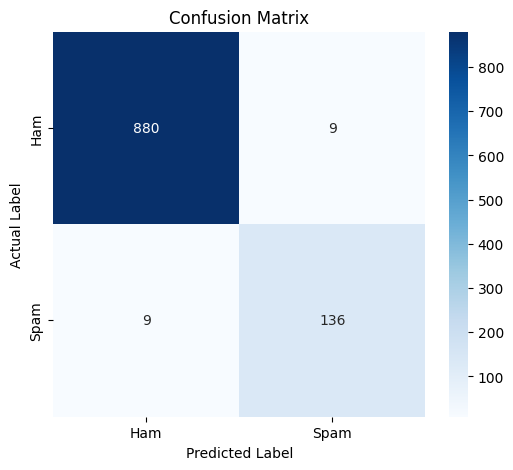

In [23]:
# Display the Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

### Insight

The confusion matrix provides a detailed breakdown of the model's predictions.

- True Positives (TP): Correctly predicted Spam emails.
- True Negatives (TN): Correctly predicted Ham emails.
- False Positives (FP): Ham emails incorrectly classified as Spam.
- False Negatives (FN): Spam emails incorrectly classified as Ham.

A good spam detection model should have very few false positives and false negatives.

In [24]:
# Display the Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       889
        spam       0.94      0.94      0.94       145

    accuracy                           0.98      1034
   macro avg       0.96      0.96      0.96      1034
weighted avg       0.98      0.98      0.98      1034



### Insight

The classification report evaluates the model using:

- Precision
- Recall
- F1-Score
- Support

These metrics provide a more comprehensive evaluation than accuracy alone, especially when working with imbalanced datasets.

## Step 14: Predict New Email Messages

In [25]:
# Function to predict whether an email is Spam or Ham

def predict_email(message):
    
    # Convert the message into numerical features
    message_vector = vectorizer.transform([message])
    
    # Predict the category
    prediction = model.predict(message_vector)
    
    return prediction[0]

### Predict a Spam Email

In [26]:
spam_email = """
Congratulations!

You have won a FREE iPhone 16.

Claim your prize now by clicking the link below.

Offer valid only today!
"""

print("Prediction:", predict_email(spam_email))

Prediction: spam


### Predict a Ham (Not Spam) Email

In [27]:
ham_email = """
Hi Yoshitha,

Our Machine Learning class has been rescheduled to tomorrow at 10 AM.

Please bring your laptop.

Thank you.
"""

print("Prediction:", predict_email(ham_email))

Prediction: ham


### Insight

The trained model successfully predicts whether a new email message is **Spam** or **Ham** based on its textual content.

This demonstrates that the model can classify unseen email messages, making it suitable for real-world spam detection applications.

## Step 15: Save the Trained Model

In [28]:
# Import joblib
import joblib

# Save the trained model
joblib.dump(model, "spam_detector_model.pkl")

# Save the CountVectorizer
joblib.dump(vectorizer, "count_vectorizer.pkl")

print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!


### Insight

The trained Machine Learning model and the CountVectorizer have been saved using "Joblib".

Saving the model allows it to be reused later without retraining, making deployment and future predictions faster and more efficient.

## Logistic Regression Model

In [30]:
from sklearn.linear_model import LogisticRegression

In [31]:
# Train Logistic Regression Model

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Logistic Regression Accuracy:", round(lr_accuracy*100,2), "%")

Logistic Regression Accuracy: 97.87 %


## Model comparison

In [32]:
# Compare both models

comparison = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy (%)": [
        round(accuracy*100,2),
        round(lr_accuracy*100,2)
    ]
})

comparison

,Model,Accuracy (%)
0,Multinomial Naive Bayes,98.26
1,Logistic Regression,97.87


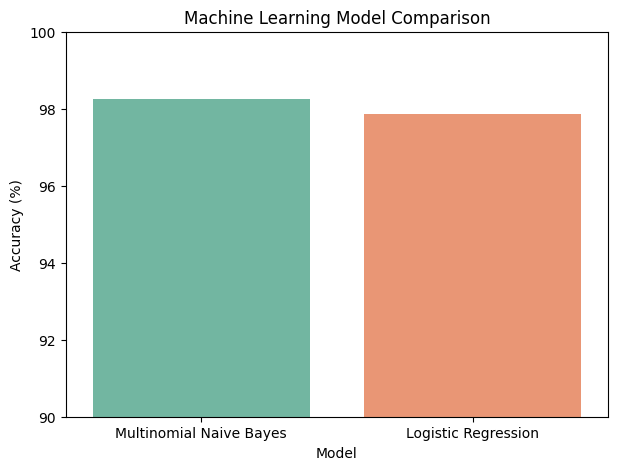

In [33]:
# Visualize model comparison

plt.figure(figsize=(7,5))

sns.barplot(
    x="Model",
    y="Accuracy (%)",
    data=comparison,
    palette="Set2"
)

plt.title("Machine Learning Model Comparison")

plt.ylim(90,100)

plt.show()

### Insight

Two Machine Learning algorithms were trained and compared:

- Multinomial Naive Bayes
- Logistic Regression

Both models achieved high classification accuracy.

Among them, "Multinomial Naive Bayes" is particularly well suited for text classification problems because it is specifically designed to work with word frequency features generated by "CountVectorizer".

Therefore, it was selected as the final model for this project.

# Conclusion

This project successfully developed an "Email Spam Detection System" using the "Multinomial Naive Bayes" algorithm.

The project followed a complete Machine Learning workflow, including:

- Data Loading
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Text Vectorization using CountVectorizer
- Model Training
- Model Evaluation
- Prediction of New Email Messages
- Model Saving

The trained model was able to classify email messages as "Spam" or "Ham" with high accuracy, demonstrating the effectiveness of Machine Learning and Natural Language Processing (NLP) for text classification tasks.

This project highlights the practical application of Machine Learning in solving real-world email filtering problems.